# Analysis of PAC comodulogram metrics 

In [39]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Binomial
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri
from rpy2.robjects.packages import importr 
from matplotlib.lines import Line2D 
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.stats import shapiro

In [ ]:
# ─── Load data ────────────────────────────────────────────────────────────────
basepath = Path('/Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis_single_trials')
open_field_LFP_csv_path = basepath / 'open_field_LFP.csv'
linear_track_LFP_csv_path = basepath / 'linear_track_LFP.csv'
OUTPUT_DIR = basepath
# os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─── Journal / Illustrator global styles ──────────────────────────────────────
mpl.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",
    "axes.grid": False,
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "ytick.left": True,
    "ytick.direction": "in",
    "savefig.transparent": True,
    "savefig.bbox": "tight",
})

GENO_ORDER  = ["WT", "NLGF"]
GENO_COLORS = {"NLGF": "#E07B54", "WT": "#5B8DB8"}

df_open_field = pd.read_csv(open_field_LFP_csv_path)
df_linear = pd.read_csv(linear_track_LFP_csv_path)

# add a new column to indicate the task
df_open_field["environment"] = "Open Field"
df_linear["environment"] = "Linear Track"

# Extract the trial letter before .set
# Example: ...trialb.set -> b
df_open_field["Trial"] = df_open_field["filename"].str.extract(r'([a-zA-Z])\.set$', expand=False)
df_linear["Trial"] = df_linear["filename"].str.extract(r'([a-zA-Z])\.set$', expand=False)

# merge the two dataframes
df = pd.concat([df_open_field, df_linear], ignore_index=True)

# Trial order
df["Trial"] = df["Trial"].astype(str).str.strip().str.lower()
df["environment"] = df["environment"].astype(str).str.strip().str.lower()

conditions = [
    (df["environment"] == "open field") & (df["Trial"] == "b"),
    (df["environment"] == "open field") & (df["Trial"] == "c"),
    (df["environment"] == "linear track") & (df["Trial"] == "a"),
    (df["environment"] == "linear track") & (df["Trial"] == "b"),
]
choices = ["first", "second", "first", "second"]
df["Trial_order"] = np.select(conditions, choices, default=np.nan)

# One row per mouse/environment/trial, with Slow/Fast values side-by-side
id_cols = [
    "mouse_name",
    "environment",
    "Trial",
    "Trial_order",
    "Genotype",
    "Experimenter",
]

# Normalize gamma band labels for robust pivoting
df["gamma_band_norm"] = df["Gamma band"].astype(str).str.strip().str.lower()

# Sanity check: max one row per id + band
check = df.groupby(id_cols + ["gamma_band_norm"]).size()
if (check > 1).any():
    print("Warning: duplicate rows found for some id + gamma_band combinations")

# Pivot both PAC max and mod index from long to wide
wide = (
    df.pivot_table(
        index=id_cols,
        columns="gamma_band_norm",
        values=["theta_gamma_comod_max", "theta_gamma_mod_index", "n_gamma_power_events"],
        aggfunc="first",
    )
)

# Rename MultiIndex columns to flat names
wide.columns = [
    (
        "comodulogram_PAC_slow_gamma" if (metric == "theta_gamma_comod_max" and band == "slow") else
        "comodulogram_PAC_fast_gamma" if (metric == "theta_gamma_comod_max" and band == "fast") else
        "theta_slow_gamma_mod_index" if (metric == "theta_gamma_mod_index" and band == "slow") else
        "theta_fast_gamma_mod_index" if (metric == "theta_gamma_mod_index" and band == "fast") else
        "n_oscillatory_epochs_slow_gamma" if (metric == "n_gamma_power_events" and band == "slow") else
        "n_oscillatory_epochs_fast_gamma" if (metric == "n_gamma_power_events" and band == "fast") else
        f"{metric}_{band}"
    )
    for metric, band in wide.columns
]
wide = wide.reset_index()

# Keep one copy of non-band columns, excluding long-format band-specific fields
other_cols = [
    c for c in df.columns
    if c not in [
        "Gamma band",
        "gamma_band_norm",
        "theta_gamma_comod_max",
        "theta_gamma_mod_index",
        "n_gamma_power_events",
        "comodulogram_PAC_slow_gamma",
        "comodulogram_PAC_fast_gamma",
        "theta_slow_gamma_mod_index",
        "theta_fast_gamma_mod_index",
        "n_oscillatory_epochs_slow_gamma",
        "n_oscillatory_epochs_fast_gamma",
    
    ]
]
base = df[other_cols].drop_duplicates(subset=id_cols)###£# Part

# Final deduplicated dataframe
df = base.merge(
    wide[
        id_cols
        + [
            "comodulogram_PAC_slow_gamma",
            "comodulogram_PAC_fast_gamma",
            "theta_slow_gamma_mod_index",
            "theta_fast_gamma_mod_index",
            "n_oscillatory_epochs_slow_gamma",
            "n_oscillatory_epochs_fast_gamma",
        ]
    ],
    on=id_cols,
    how="left",
)

# Clean names / categorical order
df["Genotype"] = pd.Categorical(df["Genotype"], categories=GENO_ORDER, ordered=True)
df["environment"] = df["environment"].astype(str)
df["mouse_name"] = df["mouse_name"].astype(str)
df["Experimenter"] = df["Experimenter"].astype(str)
df["Trial"] = df["Trial"].astype(str)

# save the merged dataframe to a new CSV file
merged_csv_path = basepath / 'merged_LFP_data.csv'
df.to_csv(merged_csv_path, index=False)
print(f"Merged dataframe saved to {merged_csv_path}")
print(f"Dataframe shape: {df.shape}")
print("-------------------------------------------------------------------------------------")
cols = df.columns.tolist()
for i in range(0, len(cols), 4):
    print(cols[i:i+4])
print("-------------------------------------------------------------------------------------")
print(df.head())

Merged dataframe saved to /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis_single_trials/merged_LFP_data.csv
Dataframe shape: (68, 21)
-------------------------------------------------------------------------------------
['filename', 'mouse_name', 'Genotype', 'power_spectrum_theta_max_freq']
['theta_running_slope', 'theta_running_intercept', 'theta_running_rvalue', 'theta_running_pvalue']
['theta_running_stderr', 'theta_running_intercept_stderr', 'Age_weeks', 'Experimenter']
['environment', 'Trial', 'Trial_order', 'comodulogram_PAC_slow_gamma']
['comodulogram_PAC_fast_gamma', 'theta_slow_gamma_mod_index', 'theta_fast_gamma_mod_index', 'n_oscillatory_epochs_slow_gamma']
['n_oscillatory_epochs_fast_gamma']
-------------------------------------------------------------------------------------
                                            filename mouse_name Genotype  \
0  /home/robin/Documents/Science/SWC/Lou

In [41]:
sub = df[(df["environment"] == "linear track") & (df["Trial_order"] == "second")]
print("rows:", len(sub))
print("animals:", sub["mouse_name"].nunique())
print(sub["mouse_name"].value_counts())

rows: 17
animals: 17
mouse_name
733075     1
1118466    1
1116810    1
1117425    1
1117201    1
708153     1
719648     1
726857     1
1117537    1
1118468    1
726050     1
644788     1
667893     1
1116806    1
1116808    1
1118674    1
1118467    1
Name: count, dtype: int64


## Run normality test for each metric

In [42]:
# ─── Metrics to analyse ───────────────────────────────────────────────────────

metrics = {
    "power_spectrum_theta_max_freq": "Theta peak frequency (Hz)",
    "comodulogram_PAC_slow_gamma": "Theta–slow gamma PAC",
    "comodulogram_PAC_fast_gamma": "Theta–fast gamma PAC",
    "n_oscillatory_epochs_slow_gamma": "Slow gamma event count",
    "n_oscillatory_epochs_fast_gamma": "Fast gamma event count",
    "theta_slow_gamma_mod_index": "Theta–Slow gamma mod index",
    "theta_fast_gamma_mod_index": "Theta–Fast gamma mod index",
    "theta_running_slope": "Theta–running slope",
    "theta_running_intercept": "Theta–running intercept",
    "theta_running_rvalue": "Theta–running r",
    "theta_running_stderr": "Theta–running stderr",
}

metrics = {k: v for k, v in metrics.items() if k in df.columns}

normality_rows = []

for env in sorted(df["environment"].dropna().unique()):
    for trial_order in ["first", "second"]:
        sub = df.loc[
            (df["environment"] == env) & (df["Trial_order"] == trial_order)
        ].copy()

        print(f"\nEnvironment: {env} | Trial: {trial_order} | n = {len(sub)}")

        for metric, label in metrics.items():
            values = sub[metric].dropna()

            if len(values) < 3:
                stat, p_value = np.nan, np.nan
                decision = "too few values"
            else:
                stat, p_value = shapiro(values)
                decision = "Normal" if p_value > 0.05 else "Not normal"

            normality_rows.append({
                "environment": env,
                "trial_order": trial_order,
                "metric": metric,
                "label": label,
                "n": len(values),
                "statistic": stat,
                "p_value": p_value,
                "decision": decision,
            })

            print(
                f"{metric}: statistic={stat:.4f} p={p_value:.4f} -> {decision}"
                if pd.notna(stat) else
                f"{metric}: too few values"
            )

normality_results = pd.DataFrame(normality_rows)
normality_results.to_csv(OUTPUT_DIR / "normality_by_env_and_trial.csv", index=False)
print("\nSaved:", OUTPUT_DIR / "normality_by_env_and_trial.csv")


Environment: linear track | Trial: first | n = 17
power_spectrum_theta_max_freq: statistic=0.9820 p=0.9730 -> Normal
comodulogram_PAC_slow_gamma: statistic=0.8208 p=0.0040 -> Not normal
comodulogram_PAC_fast_gamma: statistic=0.8983 p=0.0635 -> Normal
n_oscillatory_epochs_slow_gamma: statistic=0.7911 p=0.0015 -> Not normal
n_oscillatory_epochs_fast_gamma: statistic=0.9097 p=0.0987 -> Normal
theta_slow_gamma_mod_index: statistic=0.9539 p=0.5210 -> Normal
theta_fast_gamma_mod_index: statistic=0.9163 p=0.1278 -> Normal
theta_running_slope: statistic=0.9271 p=0.1950 -> Normal
theta_running_intercept: statistic=0.9873 p=0.9957 -> Normal
theta_running_rvalue: statistic=0.9306 p=0.2228 -> Normal
theta_running_stderr: statistic=0.9562 p=0.5620 -> Normal

Environment: linear track | Trial: second | n = 17
power_spectrum_theta_max_freq: statistic=0.9781 p=0.9376 -> Normal
comodulogram_PAC_slow_gamma: statistic=0.8574 p=0.0140 -> Not normal
comodulogram_PAC_fast_gamma: statistic=0.9224 p=0.1621 -

In [43]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.power import TTestIndPower

def _bootstrap_ci95(values, n_boot=2000, seed=10, stat_func=np.nanmedian):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) < 2:
        return np.nan

    rng = np.random.default_rng(seed)
    boot_stats = []
    for _ in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        boot_stats.append(stat_func(sample))

    return np.percentile(boot_stats, [2.5, 97.5]).tolist()

def _cohens_d(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    na = len(a)
    nb = len(b)
    if na < 2 or nb < 2:
        return np.nan

    sa = np.var(a, ddof=1)
    sb = np.var(b, ddof=1)
    pooled_sd = np.sqrt(((na - 1) * sa + (nb - 1) * sb) / (na + nb - 2))
    if pooled_sd == 0:
        return np.nan
    return (np.mean(a) - np.mean(b)) / pooled_sd

def run_group_comparison(
    df,
    value_col,
    group_col,
    group_a,
    group_b,
    test_type,
    levene_alpha=0.05,
    bootstrap_n=2000,
    bootstrap_seed=10,
):
    sub = df.loc[df[group_col].isin([group_a, group_b]), [group_col, value_col]].copy()
    sub[value_col] = pd.to_numeric(sub[value_col], errors="coerce")
    sub = sub.dropna(subset=[group_col, value_col])

    a = sub.loc[sub[group_col] == group_a, value_col].to_numpy()
    b = sub.loc[sub[group_col] == group_b, value_col].to_numpy()

    n_a = len(a)
    n_b = len(b)

    if n_a == 0 or n_b == 0:
        return {
            "test_used": np.nan,
            "statistic": np.nan,
            "p_value": np.nan,
            "dof": np.nan,
            "effect_size": np.nan,
            "ci95": np.nan,
            "power": np.nan,
            "bf10": np.nan,
            "levene_p": np.nan,
            "equal_var_assumed": np.nan,
            "n_a": n_a,
            "n_b": n_b,
        }

    levene_stat, levene_p = stats.levene(a, b, center="median")
    equal_var_assumed = bool(levene_p >= levene_alpha)

    if test_type == "parametric":
        t_res = stats.ttest_ind(a, b, equal_var=equal_var_assumed, nan_policy="omit")

        statistic = float(t_res.statistic)
        p_value = float(t_res.pvalue)
        dof = float(n_a + n_b - 2) if equal_var_assumed else np.nan
        effect_size = _cohens_d(a, b)

        mean_diff = float(np.mean(a) - np.mean(b))
        se = np.sqrt(np.var(a, ddof=1) / n_a + np.var(b, ddof=1) / n_b)
        if np.isfinite(se) and se > 0:
            if equal_var_assumed:
                crit = stats.t.ppf(0.975, n_a + n_b - 2)
            else:
                s1 = np.var(a, ddof=1) / n_a
                s2 = np.var(b, ddof=1) / n_b
                df_welch = (s1 + s2) ** 2 / ((s1 ** 2) / (n_a - 1) + (s2 ** 2) / (n_b - 1))
                crit = stats.t.ppf(0.975, df_welch)
            ci95 = [mean_diff - crit * se, mean_diff + crit * se]
        else:
            ci95 = np.nan

        if np.isfinite(effect_size) and abs(effect_size) > 0:
            power = TTestIndPower().power(
                effect_size=abs(effect_size),
                nobs1=n_a,
                ratio=n_b / n_a if n_a > 0 else np.nan,
                alpha=0.05,
                alternative="two-sided",
            )
        else:
            power = np.nan

        bf10 = np.nan
        test_used = "welch_ttest" if not equal_var_assumed else "student_ttest"

    elif test_type == "nonparametric":
        mwu = stats.mannwhitneyu(a, b, alternative="two-sided")
        statistic = float(mwu.statistic)
        p_value = float(mwu.pvalue)
        dof = np.nan
        effect_size = 1 - (2 * statistic) / (n_a * n_b)
        ci95 = _bootstrap_ci95(np.concatenate([a, b]), n_boot=bootstrap_n, seed=bootstrap_seed)
        power = np.nan
        bf10 = np.nan
        test_used = "mannwhitney_u"

    else:
        raise ValueError("test_type must be either 'parametric' or 'nonparametric'")

    return {
        "test_used": test_used,
        "statistic": statistic,
        "p_value": p_value,
        "dof": dof,
        "effect_size": effect_size,
        "ci95": ci95,
        "power": power,
        "bf10": bf10,
        "levene_p": float(levene_p),
        "equal_var_assumed": equal_var_assumed,
        "n_a": n_a,
        "n_b": n_b,
    }

In [44]:
def run_all_comparisons(
    df,
    normality_df,
    value_cols,
    group_col,
    group_a,
    group_b,
    condition_cols,
    normality_alpha=0.05,
):
    """
    For each unique combination of condition_cols in df, determine parametric vs
    non-parametric test from normality_df, then call run_group_comparison.

    normality_df must have columns: environment, trial_order, variable, p, decision
    (matches normality_results.rename(columns={"metric": "variable", "p_value": "p"}))
    """
    rows = []
    test_choice = {}

    conditions = df[condition_cols].drop_duplicates().reset_index(drop=True)

    for _, cond in conditions.iterrows():
        mask = pd.Series(True, index=df.index)
        for col in condition_cols:
            mask &= df[col] == cond[col]
        sub_df = df[mask].copy()

        if len(sub_df) == 0:
            continue

        env_val = cond.get("environment", None)
        trial_order_vals = sub_df["Trial_order"].dropna().unique()
        trial_order_val = trial_order_vals[0] if len(trial_order_vals) > 0 else None

        for value_col in value_cols:
            # Default to non-parametric; switch to parametric if normality holds
            test_type = "nonparametric"

            if normality_df is not None and trial_order_val is not None and env_val is not None:
                norm_row = normality_df[
                    (normality_df["variable"] == value_col)
                    & (normality_df["environment"] == env_val)
                    & (normality_df["trial_order"] == trial_order_val)
                ]
                if len(norm_row) > 0:
                    p_norm = norm_row["p"].iloc[0]
                    if pd.notna(p_norm) and p_norm > normality_alpha:
                        test_type = "parametric"

            result = run_group_comparison(
                df=sub_df,
                value_col=value_col,
                group_col=group_col,
                group_a=group_a,
                group_b=group_b,
                test_type=test_type,
            )

            row = {
                **{col: cond[col] for col in condition_cols},
                "variable": value_col,
                "test_family": test_type,
                **result,
            }
            rows.append(row)

            key = tuple(cond[col] for col in condition_cols) + (value_col,)
            test_choice[key] = test_type

    return pd.DataFrame(rows), test_choice

In [45]:
results_df, test_choice = run_all_comparisons(
    df=df,
    normality_df=normality_results.rename(columns={"metric": "variable", "p_value": "p"}),
    value_cols=list(metrics.keys()),  # Use only metrics that exist in df
    group_col="Genotype",
    group_a="WT",
    group_b="NLGF",
    condition_cols=["environment", "Trial"],
)

save_path = OUTPUT_DIR / "statistics.csv"
results_df.to_csv(save_path, index=False)
print(f"\nSaved comparison results to {save_path}")

print("\nComparison results:")
print(results_df.head(50))


Saved comparison results to /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis_single_trials/statistics.csv

Comparison results:
     environment Trial                         variable    test_family  \
0     open field     b    power_spectrum_theta_max_freq     parametric   
1     open field     b      comodulogram_PAC_slow_gamma     parametric   
2     open field     b      comodulogram_PAC_fast_gamma  nonparametric   
3     open field     b  n_oscillatory_epochs_slow_gamma     parametric   
4     open field     b  n_oscillatory_epochs_fast_gamma     parametric   
5     open field     b       theta_slow_gamma_mod_index     parametric   
6     open field     b       theta_fast_gamma_mod_index     parametric   
7     open field     b              theta_running_slope     parametric   
8     open field     b          theta_running_intercept     parametric   
9     open field     b             theta_running

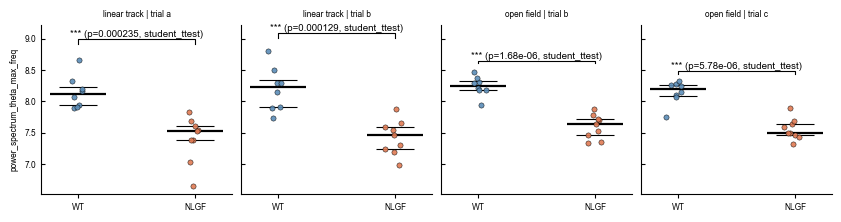

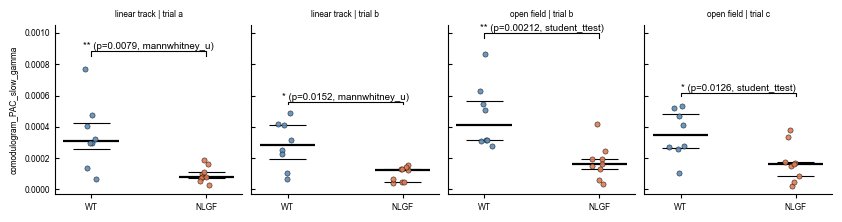

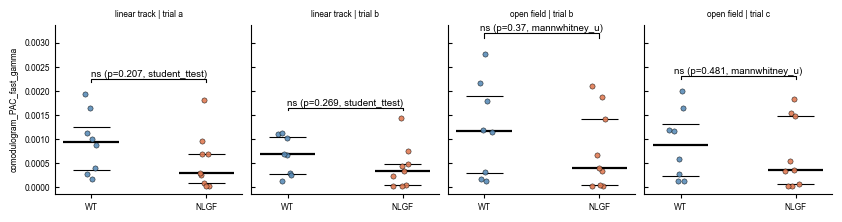

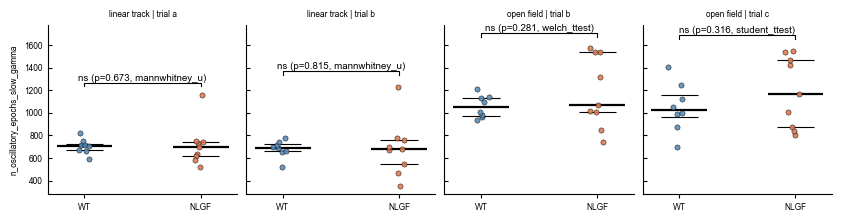

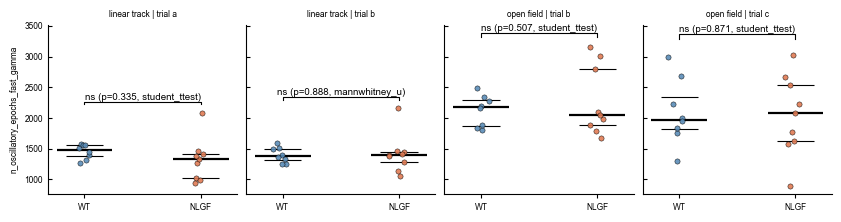

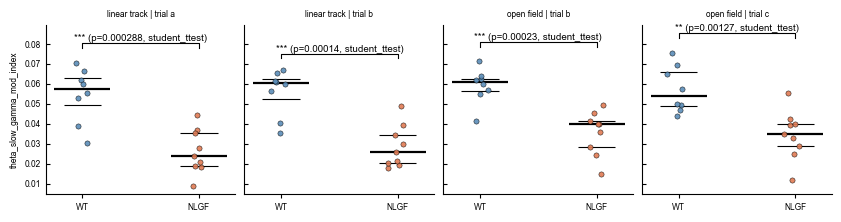

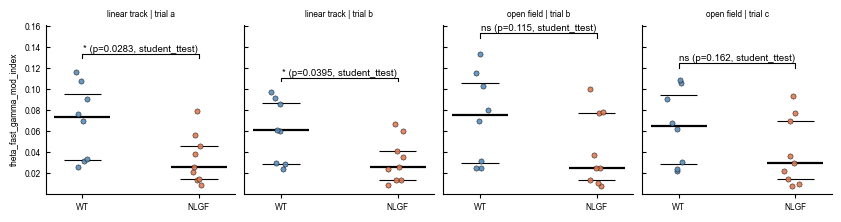

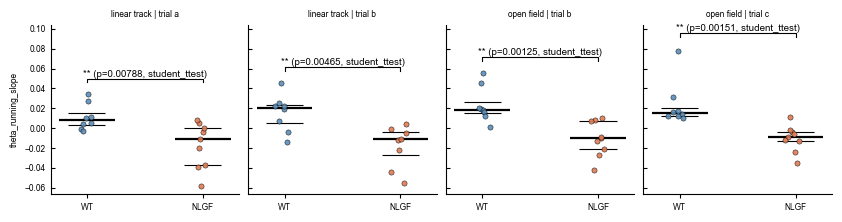

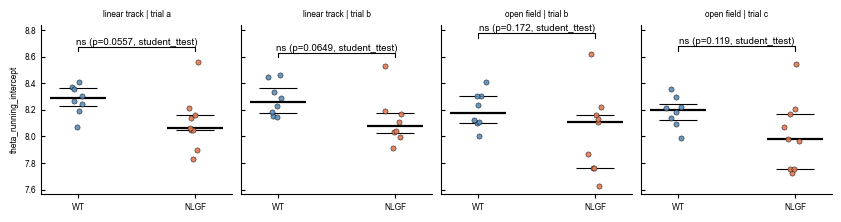

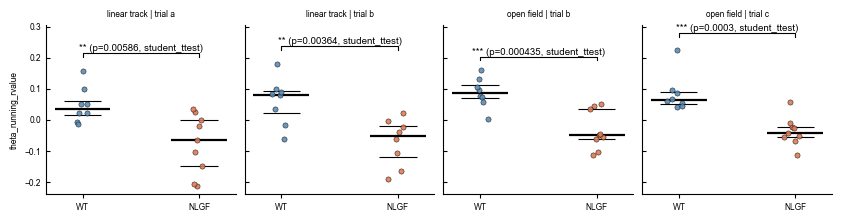

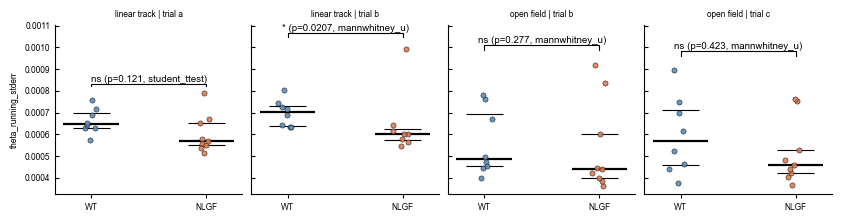

In [46]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

GENO_ORDER = ["WT", "NLGF"]
GENO_COLORS = {"WT": "#5B8DB8", "NLGF": "#E07B54"}

def p_to_stars(p):
    if pd.isna(p):
        return "ns"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

def plot_metric_from_results(df, results_df, metric, save=True):
    cond = (
        df[["environment", "Trial"]]
        .drop_duplicates()
        .sort_values(["environment", "Trial"])
        .to_dict("records")
    )

    if len(cond) == 0:
        return

    fig, axes = plt.subplots(1, len(cond), figsize=(2.1 * len(cond), 2.2), sharey=True)
    if len(cond) == 1:
        axes = [axes]

    rng = np.random.default_rng(10)

    for ax, c in zip(axes, cond):
        env = c["environment"]
        trial = c["Trial"]

        sub = df.loc[
            (df["environment"] == env) &
            (df["Trial"] == trial),
            ["Genotype", "mouse_name", metric]
        ].dropna()

        vals = {}
        for g in GENO_ORDER:
            vals[g] = sub.loc[sub["Genotype"].astype(str) == g, metric].to_numpy()

        for xi, g in enumerate(GENO_ORDER):
            y = vals[g]
            if len(y) == 0:
                continue

            q1 = np.nanpercentile(y, 25)
            med = np.nanmedian(y)
            q3 = np.nanpercentile(y, 75)

            ax.hlines([q1, q3], xi - 0.16, xi + 0.16, colors="black", linewidth=0.8, zorder=7)
            ax.hlines(med, xi - 0.24, xi + 0.24, colors="black", linewidth=1.6, zorder=8)

            jitter = rng.normal(0, 0.045, size=len(y))
            ax.scatter(
                np.full(len(y), xi) + jitter,
                y,
                s=14,
                color=GENO_COLORS.get(g, "#aaaaaa"),
                edgecolor="black",
                linewidth=0.35,
                alpha=0.9,
                zorder=10,
            )

        r = results_df.loc[
            (results_df["variable"] == metric) &
            (results_df["environment"] == env) &
            (results_df["Trial"] == trial)
        ]

        if len(r) > 0:
            p = pd.to_numeric(r["p_value"].iloc[0], errors="coerce")
            test_used = str(r["test_used"].iloc[0])

            if sub[metric].notna().any():
                ymax = float(np.nanmax(sub[metric].values))
                ymin = float(np.nanmin(sub[metric].values))
                yrng = (ymax - ymin) if ymax > ymin else max(abs(ymax) * 0.1, 1.0)
                y = ymax + 0.12 * yrng
                h = 0.04 * yrng

                ax.plot([0, 0, 1, 1], [y, y + h, y + h, y], color="black", linewidth=0.8, clip_on=False)
                ax.text(
                    0.5,
                    y + h,
                    f"{p_to_stars(p)} (p={p:.3g}, {test_used})",
                    ha="center",
                    va="bottom",
                    fontsize=7,
                )

        ax.set_xticks(range(len(GENO_ORDER)))
        ax.set_xticklabels(GENO_ORDER)
        ax.set_title(f"{env} | trial {trial}")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel(metric)
    fig.tight_layout()

    if save:
        clean_metric = metric.replace("/", "_")
        fig.savefig(os.path.join(OUTPUT_DIR, f"{clean_metric}_by_env_trial_from_results.pdf"))

    plt.show()
    plt.close(fig)

# plot all variables that were tested above
for metric in [m for m in results_df["variable"].dropna().unique() if m in df.columns]:
    plot_metric_from_results(df, results_df, metric, save=True)

## Mixed GLMM-TMB models for all metrics 

In [47]:
# ── Mixed GLMM-TMB models for all metrics ────────────────────────────────────
# Paired (slow/fast): value ~ Genotype * gamma_band * Trial_order + (1|mouse_name)
# Scalar:             value ~ Genotype * Trial_order + (1|mouse_name)
# Family selection: Gaussian vs Gamma vs Inverse Gaussian, selected by AIC

import pandas as pd
import numpy as np
from pathlib import Path
import traceback
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

ro.r("suppressPackageStartupMessages(library(glmmTMB))")
ro.r("suppressPackageStartupMessages(library(car))")
ro.r("suppressPackageStartupMessages(library(emmeans))")

def sig_label(p):
    if pd.isna(p): return 'NA'
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'


for env in sorted(df["environment"].dropna().unique()):
    sub_df = df[df["environment"] == env].copy()
    env_clean = str(env).strip().replace(" ", "_").replace("/", "_")
    print(f"\n{'='*80}\nENVIRONMENT: {env}\n{'='*80}")

    # ── Metric definitions ────────────────────────────────────────────────────────
    PAIRED_METRICS = {k: v for k, v in {
        'PAC': {
            'slow': 'comodulogram_PAC_slow_gamma',
            'fast': 'comodulogram_PAC_fast_gamma',
            'label': 'Theta-gamma PAC',
        },
        'mod_index': {
            'slow': 'theta_slow_gamma_mod_index',
            'fast': 'theta_fast_gamma_mod_index',
            'label': 'Theta-gamma modulation index',
        },
        'n_oscillatory_epochs': {
            'slow': 'n_oscillatory_epochs_slow_gamma',
            'fast': 'n_oscillatory_epochs_fast_gamma',
            'label': 'N oscillatory epochs',
        },
    }.items() if v['slow'] in df.columns and v['fast'] in df.columns}

    SCALAR_METRICS = {k: v for k, v in {
        'power_spectrum_theta_max_freq': 'Theta peak frequency (Hz)',
        'theta_running_slope':           'Theta-running slope',
        'theta_running_intercept':       'Theta-running intercept',
        'theta_running_rvalue':          'Theta-running r value',
    }.items() if k in df.columns}

    out_dir = Path(OUTPUT_DIR) / 'glmmTMB_all_metrics_trial_order'
    out_dir.mkdir(parents=True, exist_ok=True)
    # Environment is included in each filename to avoid open_field/linear_track overwrites.

    all_glmmTMB_results = {}
    family_summary_all = []

    # ── R helpers ────────────────────────────────────────────────────────────────
    _PAIRED_RCODE = """
    suppressWarnings({
        dat$mouse_name  <- factor(dat$mouse_name)
        dat$Genotype    <- factor(dat$Genotype,    levels = c("WT", "NLGF"))
        dat$gamma_band  <- factor(dat$gamma_band,  levels = c("slow", "fast"))
        dat$Trial_order <- factor(dat$Trial_order, levels = c("first", "second"))

        contrasts(dat$Genotype)    <- contr.sum(nlevels(dat$Genotype))
        contrasts(dat$gamma_band)  <- contr.sum(nlevels(dat$gamma_band))
        contrasts(dat$Trial_order) <- contr.sum(nlevels(dat$Trial_order))

        fit_gaussian <- tryCatch(
            glmmTMB(value ~ Genotype * gamma_band * Trial_order + (1 | mouse_name),
                    data = dat, family = gaussian()),
            error = function(e) NULL
        )
        fit_gamma <- tryCatch(
            glmmTMB(value_pos ~ Genotype * gamma_band * Trial_order + (1 | mouse_name),
                    data = dat, family = Gamma(link = "log")),
            error = function(e) NULL
        )
        fit_igaussian <- tryCatch(
            glmmTMB(value_pos ~ Genotype * gamma_band * Trial_order + (1 | mouse_name),
                    data = dat, family = inverse.gaussian(link = "log")),
            error = function(e) NULL
        )

        safe_aic <- function(fit) if (is.null(fit)) Inf else AIC(fit)
        aic_list <- c(
            gaussian  = safe_aic(fit_gaussian),
            gamma     = safe_aic(fit_gamma),
            igaussian = safe_aic(fit_igaussian)
        )
        if (!any(is.finite(aic_list))) stop("All candidate families failed")

        best_family_name <- names(which.min(aic_list))
        best_fit <- if (best_family_name == "gaussian") fit_gaussian
                    else if (best_family_name == "gamma") fit_gamma
                    else fit_igaussian

        delta_aic_from_best <- aic_list - min(aic_list, na.rm = TRUE)

        aov_table <- as.data.frame(Anova(best_fit, type = 3))
        aov_table <- data.frame(term = rownames(aov_table), aov_table,
                                row.names = NULL, check.names = FALSE)

        emm_geno  <- emmeans(best_fit, ~ Genotype | gamma_band * Trial_order)
        emm_trial <- emmeans(best_fit, ~ Trial_order | Genotype * gamma_band)
        emm_band  <- emmeans(best_fit, ~ gamma_band | Genotype * Trial_order)

        vc <- VarCorr(best_fit)$cond$mouse_name
        re_var <- if (is.null(vc)) NA_real_ else as.numeric(vc[1,1])

        list(
            best_family    = best_family_name,
            aic_gaussian   = aic_list[["gaussian"]],
            aic_gamma      = aic_list[["gamma"]],
            aic_igaussian  = aic_list[["igaussian"]],
            delta_aics     = delta_aic_from_best,
            aic_best       = AIC(best_fit),
            anova_table    = aov_table,
            geno_contrasts = as.data.frame(contrast(emm_geno,  method = "pairwise")),
            trial_contrasts = as.data.frame(contrast(emm_trial, method = "pairwise")),
            band_contrasts = as.data.frame(contrast(emm_band,  method = "pairwise")),
            re_var         = re_var
        )
    })
    """

    _SCALAR_RCODE = """
    suppressWarnings({
        dat$mouse_name  <- factor(dat$mouse_name)
        dat$Genotype    <- factor(dat$Genotype,    levels = c("WT", "NLGF"))
        dat$Trial_order <- factor(dat$Trial_order, levels = c("first", "second"))

        contrasts(dat$Genotype)    <- contr.sum(nlevels(dat$Genotype))
        contrasts(dat$Trial_order) <- contr.sum(nlevels(dat$Trial_order))

        fit_gaussian <- tryCatch(
            glmmTMB(value ~ Genotype * Trial_order + (1 | mouse_name),
                    data = dat, family = gaussian()),
            error = function(e) NULL
        )
        fit_gamma <- tryCatch(
            glmmTMB(value_pos ~ Genotype * Trial_order + (1 | mouse_name),
                    data = dat, family = Gamma(link = "log")),
            error = function(e) NULL
        )
        fit_igaussian <- tryCatch(
            glmmTMB(value_pos ~ Genotype * Trial_order + (1 | mouse_name),
                    data = dat, family = inverse.gaussian(link = "log")),
            error = function(e) NULL
        )

        safe_aic <- function(fit) if (is.null(fit)) Inf else AIC(fit)
        aic_list <- c(
            gaussian  = safe_aic(fit_gaussian),
            gamma     = safe_aic(fit_gamma),
            igaussian = safe_aic(fit_igaussian)
        )
        if (!any(is.finite(aic_list))) stop("All candidate families failed")

        best_family_name <- names(which.min(aic_list))
        best_fit <- if (best_family_name == "gaussian") fit_gaussian
                    else if (best_family_name == "gamma") fit_gamma
                    else fit_igaussian

        delta_aic_from_best <- aic_list - min(aic_list, na.rm = TRUE)

        aov_table <- as.data.frame(Anova(best_fit, type = 3))
        aov_table <- data.frame(term = rownames(aov_table), aov_table,
                                row.names = NULL, check.names = FALSE)

        emm_geno  <- emmeans(best_fit, ~ Genotype | Trial_order)
        emm_trial <- emmeans(best_fit, ~ Trial_order | Genotype)

        vc <- VarCorr(best_fit)$cond$mouse_name
        re_var <- if (is.null(vc)) NA_real_ else as.numeric(vc[1,1])

        list(
            best_family    = best_family_name,
            aic_gaussian   = aic_list[["gaussian"]],
            aic_gamma      = aic_list[["gamma"]],
            aic_igaussian  = aic_list[["igaussian"]],
            delta_aics     = delta_aic_from_best,
            aic_best       = AIC(best_fit),
            anova_table    = aov_table,
            geno_contrasts = as.data.frame(contrast(emm_geno,  method = "pairwise")),
            trial_contrasts = as.data.frame(contrast(emm_trial, method = "pairwise")),
            re_var         = re_var
        )
    })
    """

    def _add_positive_response(dat):
        dat = dat.copy()
        min_value = dat['value'].min()
        min_positive = dat.loc[dat['value'] > 0, 'value'].min()
        base_offset = min_positive / 2 if pd.notna(min_positive) else 1e-5

        if pd.isna(min_value):
            shift = 0.0
        elif min_value <= 0:
            shift = abs(min_value) + base_offset
        else:
            shift = 0.0

        dat['value_pos'] = dat['value'] + shift
        dat.loc[dat['value_pos'] <= 0, 'value_pos'] = base_offset
        return dat, shift, base_offset

    def _levels_ok(dat, cols):
        missing = [col for col in cols if dat[col].dropna().nunique() < 2]
        if missing:
            print(f"  Skipped: fewer than two levels for {', '.join(missing)}")
            return False
        return True

    def _run_r_model(dat, r_code):
        with localconverter(ro.default_converter + pandas2ri.converter):
            ro.globalenv['dat'] = ro.conversion.py2rpy(dat)
        out = ro.r(r_code)
        with localconverter(ro.default_converter + pandas2ri.converter):
            aov_df = ro.conversion.rpy2py(out.rx2('anova_table'))
            geno_contrasts = ro.conversion.rpy2py(out.rx2('geno_contrasts'))
            trial_contrasts = ro.conversion.rpy2py(out.rx2('trial_contrasts'))
            band_contrasts = None
            if 'band_contrasts' in list(out.names):
                band_contrasts = ro.conversion.rpy2py(out.rx2('band_contrasts'))

        return {
            'best_family': str(out.rx2('best_family')[0]),
            'aic_gaussian': float(out.rx2('aic_gaussian')[0]),
            'aic_gamma': float(out.rx2('aic_gamma')[0]),
            'aic_igaussian': float(out.rx2('aic_igaussian')[0]),
            'aic_best': float(out.rx2('aic_best')[0]),
            're_var': float(out.rx2('re_var')[0]) if not pd.isna(float(out.rx2('re_var')[0])) else np.nan,
            'anova': aov_df,
            'geno_contrasts': geno_contrasts,
            'trial_contrasts': trial_contrasts,
            'band_contrasts': band_contrasts,
        }

    def _print_family_selection(res):
        print("\nFamily selection (Type III via car::Anova):")
        print(f"  Gaussian:         AIC = {res['aic_gaussian']:.2f}")
        print(f"  Gamma:            AIC = {res['aic_gamma']:.2f}")
        print(f"  Inverse Gaussian: AIC = {res['aic_igaussian']:.2f}")
        print(f"  Best fit:         {res['best_family'].upper()} (AIC = {res['aic_best']:.2f})")
        print(f"  RE variance (mouse): {res['re_var']:.6f}")

    # ── Run paired metrics ────────────────────────────────────────────────────────
    for metric_name, meta in PAIRED_METRICS.items():
        print(f"\n{'='*80}\nPAIRED: {metric_name} ({meta['label']})\n{'='*80}")
        try:
            slow = sub_df[['mouse_name', 'Genotype', 'Trial_order', meta['slow']]].rename(columns={meta['slow']: 'value'})
            slow['gamma_band'] = 'slow'
            fast = sub_df[['mouse_name', 'Genotype', 'Trial_order', meta['fast']]].rename(columns={meta['fast']: 'value'})
            fast['gamma_band'] = 'fast'
            long_df = pd.concat([slow, fast], ignore_index=True).dropna(subset=['value', 'Trial_order'])

            for col in ['mouse_name', 'Genotype', 'gamma_band', 'Trial_order']:
                long_df[col] = long_df[col].astype(str)
            long_df, shift, base_offset = _add_positive_response(long_df)

            print(f"n rows = {len(long_df)}, n mice = {long_df['mouse_name'].nunique()}")
            print(f"{metric_name} range: [{long_df['value'].min():.6f}, {long_df['value'].max():.6f}]")
            print(f"Positive-response shift for Gamma/IG: {shift:.6g}; fallback offset: {base_offset:.6g}")
            print(long_df.groupby(['Trial_order', 'Genotype', 'gamma_band'])['value'].agg(['count', 'median']))

            if long_df['mouse_name'].nunique() < 4 or not _levels_ok(long_df, ['Genotype', 'gamma_band', 'Trial_order']):
                continue

            res = _run_r_model(long_df, _PAIRED_RCODE)
            _print_family_selection(res)

            print(f"\n--- Type III ANOVA ({res['best_family']}) ---")
            print(res['anova'].to_string(index=False))
            print("\n--- Genotype contrasts within gamma_band x Trial_order ---")
            print(res['geno_contrasts'].to_string(index=False))
            print("\n--- Trial_order contrasts within Genotype x gamma_band ---")
            print(res['trial_contrasts'].to_string(index=False))
            print("\n--- Gamma-band contrasts within Genotype x Trial_order ---")
            print(res['band_contrasts'].to_string(index=False))

            metric_clean = metric_name.replace(' ', '_')
            res['anova'].to_csv(out_dir / f"glmmTMB_{metric_clean}_{env_clean}_anova_{res['best_family']}.csv", index=False)
            res['geno_contrasts'].to_csv(out_dir / f"glmmTMB_{metric_clean}_{env_clean}_geno_contrasts_{res['best_family']}.csv", index=False)
            res['trial_contrasts'].to_csv(out_dir / f"glmmTMB_{metric_clean}_{env_clean}_trial_contrasts_{res['best_family']}.csv", index=False)
            res['band_contrasts'].to_csv(out_dir / f"glmmTMB_{metric_clean}_{env_clean}_band_contrasts_{res['best_family']}.csv", index=False)

            all_glmmTMB_results[metric_name] = res
            family_summary_all.append({
                'environment': env,
                'metric': metric_name,
                'metric_type': 'paired',
                'best_family': res['best_family'],
                'aic_gaussian': res['aic_gaussian'],
                'aic_gamma': res['aic_gamma'],
                'aic_igaussian': res['aic_igaussian'],
                'n_rows': len(long_df),
                'n_mice': long_df['mouse_name'].nunique(),
                'positive_response_shift': shift,
            })

        except Exception as e:
            print(f"  FAILED: {e}")
            traceback.print_exc()

    # ── Run scalar metrics ────────────────────────────────────────────────────────
    for metric_name, label in SCALAR_METRICS.items():
        print(f"\n{'='*80}\nSCALAR: {metric_name} ({label})\n{'='*80}")
        try:
            sub = (
                sub_df[['mouse_name', 'Genotype', 'Trial_order', metric_name]]
                .rename(columns={metric_name: 'value'})
                .dropna(subset=['value', 'Trial_order'])
                .copy()
            )
            for col in ['mouse_name', 'Genotype', 'Trial_order']:
                sub[col] = sub[col].astype(str)
            sub, shift, base_offset = _add_positive_response(sub)

            print(f"n rows = {len(sub)}, n mice = {sub['mouse_name'].nunique()}")
            print(f"{metric_name} range: [{sub['value'].min():.6f}, {sub['value'].max():.6f}]")
            print(f"Positive-response shift for Gamma/IG: {shift:.6g}; fallback offset: {base_offset:.6g}")
            print(sub.groupby(['Trial_order', 'Genotype'])['value'].agg(['count', 'median']))

            if sub['mouse_name'].nunique() < 4 or not _levels_ok(sub, ['Genotype', 'Trial_order']):
                continue

            res = _run_r_model(sub, _SCALAR_RCODE)
            _print_family_selection(res)

            print(f"\n--- Type III ANOVA ({res['best_family']}) ---")
            print(res['anova'].to_string(index=False))
            print("\n--- Genotype contrasts within Trial_order ---")
            print(res['geno_contrasts'].to_string(index=False))
            print("\n--- Trial_order contrasts within Genotype ---")
            print(res['trial_contrasts'].to_string(index=False))

            metric_clean = metric_name.replace(' ', '_')
            res['anova'].to_csv(out_dir / f"glmmTMB_{metric_clean}_{env_clean}_anova_{res['best_family']}.csv", index=False)
            res['geno_contrasts'].to_csv(out_dir / f"glmmTMB_{metric_clean}_{env_clean}_geno_contrasts_{res['best_family']}.csv", index=False)
            res['trial_contrasts'].to_csv(out_dir / f"glmmTMB_{metric_clean}_{env_clean}_trial_contrasts_{res['best_family']}.csv", index=False)

            all_glmmTMB_results[metric_name] = res
            family_summary_all.append({
                'environment': env,
                'metric': metric_name,
                'metric_type': 'scalar',
                'best_family': res['best_family'],
                'aic_gaussian': res['aic_gaussian'],
                'aic_gamma': res['aic_gamma'],
                'aic_igaussian': res['aic_igaussian'],
                'n_rows': len(sub),
                'n_mice': sub['mouse_name'].nunique(),
                'positive_response_shift': shift,
            })

        except Exception as e:
            print(f"  FAILED: {e}")
            traceback.print_exc()

    # ── Summary ──────────────────────────────────────────────────────────────────
    if family_summary_all:
        family_summary_df = pd.DataFrame(family_summary_all)
        print(f"\n{'='*80}\nSUMMARY: FAMILIES SELECTED FOR ALL METRICS\n{'='*80}")
        print(family_summary_df.to_string(index=False))
        family_summary_df.to_csv(out_dir / f'family_selection_summary_{env_clean}_all_metrics.csv', index=False)

    print(f"\nDone. Results saved to: {out_dir}")





ENVIRONMENT: linear track

PAIRED: PAC (Theta-gamma PAC)
n rows = 68, n mice = 17
PAC range: [0.000019, 0.001948]
Positive-response shift for Gamma/IG: 0; fallback offset: 9.75e-06
                                 count    median
Trial_order Genotype gamma_band                 
first       NLGF     fast            9  0.000305
                     slow            9  0.000081
            WT       fast            8  0.000938
                     slow            8  0.000310
second      NLGF     fast            9  0.000344
                     slow            9  0.000126
            WT       fast            8  0.000687
                     slow            8  0.000283

Family selection (Type III via car::Anova):
  Gaussian:         AIC = -874.82
  Gamma:            AIC = -958.28
  Inverse Gaussian: AIC = -943.11
  Best fit:         GAMMA (AIC = -958.28)
  RE variance (mouse): 0.290190

--- Type III ANOVA (gamma) ---
                           term       Chisq  Df   Pr(>Chisq)
              

## Compare GLMM-TMB vs Mann-Whitney U: concordance of genotype effects


This comparison uses the environment-specific GLMM-TMB genotype contrasts and recomputes Mann-Whitney U tests directly from `df` for the same `environment`, `Trial_order`, and original metric column.

For paired slow/fast metrics, GLMM-TMB rows are mapped back to the matching original slow/fast columns before running Mann-Whitney. This makes the concordance table compare like-for-like genotype effects: WT vs NLGF within the same environment and trial order.


In [48]:
# ── Compare GLMM-TMB vs Mann-Whitney U: genotype contrast concordance ────────
# Compares WT vs NLGF from GLMM-TMB genotype contrast CSVs against Mann-Whitney U
# computed directly from df for the same environment, Trial_order, and metric.

from pathlib import Path
from IPython.display import display, HTML
import numpy as np
import pandas as pd
from scipy import stats

ALPHA = 0.05
GLMM_DIR = Path(OUTPUT_DIR) / "glmmTMB_all_metrics_trial_order"

GENOTYPE_A = "WT"
GENOTYPE_B = "NLGF"

PAIRED_ORIGINAL_METRIC = {
    ("PAC", "slow"): "comodulogram_PAC_slow_gamma",
    ("PAC", "fast"): "comodulogram_PAC_fast_gamma",
    ("mod_index", "slow"): "theta_slow_gamma_mod_index",
    ("mod_index", "fast"): "theta_fast_gamma_mod_index",
    ("n_oscillatory_epochs", "slow"): "n_oscillatory_epochs_slow_gamma",
    ("n_oscillatory_epochs", "fast"): "n_oscillatory_epochs_fast_gamma",
}

SCALAR_ORIGINAL_METRIC = {
    "power_spectrum_theta_max_freq": "power_spectrum_theta_max_freq",
    "theta_running_slope": "theta_running_slope",
    "theta_running_intercept": "theta_running_intercept",
    "theta_running_rvalue": "theta_running_rvalue",
}

def sig_label(p):
    if pd.isna(p): return "NA"
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def clean_key(value):
    return str(value).strip().lower().replace(" ", "_").replace("/", "_")

def parse_glmm_geno_filename(path, env_lookup):
    """Return metric, environment, family from glmmTMB_{metric}_{env}_geno_contrasts_{family}.csv."""
    name = path.name
    if not (name.startswith("glmmTMB_") and "_geno_contrasts_" in name and name.endswith(".csv")):
        return None

    stem = name.removeprefix("glmmTMB_").removesuffix(".csv")
    for env_clean, env_label in sorted(env_lookup.items(), key=lambda item: len(item[0]), reverse=True):
        marker = f"_{env_clean}_geno_contrasts_"
        if marker in stem:
            metric_name, family = stem.split(marker, 1)
            return metric_name, env_label, family
    return None

def mann_whitney_for_metric(data, metric_col, environment, trial_order):
    sub = data.loc[
        (data["environment"].map(clean_key) == clean_key(environment))
        & (data["Trial_order"].map(clean_key) == clean_key(trial_order))
        & (data["Genotype"].astype(str).isin([GENOTYPE_A, GENOTYPE_B])),
        ["Genotype", metric_col],
    ].copy()
    sub[metric_col] = pd.to_numeric(sub[metric_col], errors="coerce")
    sub = sub.dropna(subset=[metric_col])

    a = sub.loc[sub["Genotype"].astype(str) == GENOTYPE_A, metric_col].to_numpy()
    b = sub.loc[sub["Genotype"].astype(str) == GENOTYPE_B, metric_col].to_numpy()

    if len(a) == 0 or len(b) == 0:
        return {
            "mwu_U": np.nan,
            "mwu_p": np.nan,
            "mwu_effect_size_rank_biserial": np.nan,
            "n_WT": len(a),
            "n_NLGF": len(b),
            "WT_median": np.nan if len(a) == 0 else np.nanmedian(a),
            "NLGF_median": np.nan if len(b) == 0 else np.nanmedian(b),
            "median_diff_WT_minus_NLGF": np.nan,
        }

    res = stats.mannwhitneyu(a, b, alternative="two-sided")
    return {
        "mwu_U": float(res.statistic),
        "mwu_p": float(res.pvalue),
        "mwu_effect_size_rank_biserial": 1 - (2 * float(res.statistic)) / (len(a) * len(b)),
        "n_WT": len(a),
        "n_NLGF": len(b),
        "WT_median": float(np.nanmedian(a)),
        "NLGF_median": float(np.nanmedian(b)),
        "median_diff_WT_minus_NLGF": float(np.nanmedian(a) - np.nanmedian(b)),
    }

def classify_concordance(glmm_sig, mwu_sig):
    if glmm_sig and mwu_sig:
        return "both_significant"
    if glmm_sig and not mwu_sig:
        return "glmm_only"
    if (not glmm_sig) and mwu_sig:
        return "mwu_only"
    return "both_not_significant"

if not GLMM_DIR.exists():
    raise FileNotFoundError(f"GLMM-TMB results folder not found: {GLMM_DIR}")

env_lookup = {clean_key(env): env for env in sorted(df["environment"].dropna().unique())}
rows = []

for path in sorted(GLMM_DIR.glob("glmmTMB_*_geno_contrasts_*.csv")):
    parsed = parse_glmm_geno_filename(path, env_lookup)
    if parsed is None:
        print(f"Skipping unrecognized GLMM filename: {path.name}")
        continue

    metric_name, environment, family = parsed
    glmm = pd.read_csv(path)

    if "p.value" not in glmm.columns:
        print(f"Skipping {path.name}: no p.value column")
        continue

    for _, row in glmm.iterrows():
        gamma_band = row.get("gamma_band", np.nan)
        trial_order = row.get("Trial_order", np.nan)

        if pd.isna(trial_order):
            print(f"Skipping {path.name}: missing Trial_order")
            continue

        if pd.notna(gamma_band):
            original_metric = PAIRED_ORIGINAL_METRIC.get((metric_name, str(gamma_band)))
            metric_type = "paired"
        else:
            original_metric = SCALAR_ORIGINAL_METRIC.get(metric_name, metric_name)
            metric_type = "scalar"

        if original_metric not in df.columns:
            print(f"Skipping {path.name}: {original_metric!r} not found in df")
            continue

        glmm_p = pd.to_numeric(row.get("p.value"), errors="coerce")
        mwu = mann_whitney_for_metric(df, original_metric, environment, trial_order)
        mwu_p = mwu["mwu_p"]

        glmm_sig = bool(pd.notna(glmm_p) and glmm_p < ALPHA)
        mwu_sig = bool(pd.notna(mwu_p) and mwu_p < ALPHA)

        rows.append({
            "environment": environment,
            "Trial_order": trial_order,
            "metric": metric_name,
            "metric_type": metric_type,
            "gamma_band": gamma_band,
            "original_metric": original_metric,
            "family": family,
            "glmm_contrast": row.get("contrast", np.nan),
            "glmm_estimate": row.get("estimate", np.nan),
            "glmm_SE": row.get("SE", np.nan),
            "glmm_df": row.get("df", np.nan),
            "glmm_stat": row.get("z.ratio", row.get("t.ratio", np.nan)),
            "glmm_p": glmm_p,
            "glmm_sig": glmm_sig,
            "glmm_sig_label": sig_label(glmm_p),
            **mwu,
            "mwu_sig": mwu_sig,
            "mwu_sig_label": sig_label(mwu_p),
            "concordance": classify_concordance(glmm_sig, mwu_sig),
            "source_file": path.name,
        })

comparison = pd.DataFrame(rows)

if comparison.empty:
    raise RuntimeError(f"No comparable GLMM-TMB genotype contrast rows were found in {GLMM_DIR}")

comparison = comparison.sort_values([
    "environment",
    "Trial_order",
    "metric_type",
    "metric",
    "gamma_band",
    "original_metric",
]).reset_index(drop=True)

significant_summary = comparison.loc[
    comparison["glmm_sig"] | comparison["mwu_sig"]
].copy()

comparison_path = GLMM_DIR / "glmmTMB_vs_mannwhitney_concordance.csv"
significant_path = GLMM_DIR / "glmmTMB_vs_mannwhitney_significant_results.csv"
comparison.to_csv(comparison_path, index=False)
significant_summary.to_csv(significant_path, index=False)

print(f"Saved full concordance table: {comparison_path}")
print(f"Saved significant-results table: {significant_path}")
print("\nConcordance counts:")
print(comparison["concordance"].value_counts(dropna=False).to_string())

print("\nConcordance by environment:")
print(pd.crosstab(comparison["environment"], comparison["concordance"]).to_string())

print("\nSignificant GLMM-TMB or Mann-Whitney results:")
display_cols = [
    "environment", "Trial_order", "original_metric", "gamma_band", "family",
    "glmm_estimate", "glmm_p", "glmm_sig_label", "mwu_U", "mwu_p", "mwu_sig_label",
    "WT_median", "NLGF_median", "concordance",
]
if significant_summary.empty:
    print("No significant GLMM-TMB or Mann-Whitney genotype contrasts at alpha =", ALPHA)
else:
    display(significant_summary[display_cols])

# Keep a compact object in memory for downstream cells.
glmmTMB_vs_mwu = comparison



Saved full concordance table: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis_single_trials/glmmTMB_all_metrics_trial_order/glmmTMB_vs_mannwhitney_concordance.csv
Saved significant-results table: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis_single_trials/glmmTMB_all_metrics_trial_order/glmmTMB_vs_mannwhitney_significant_results.csv

Concordance counts:
concordance
both_significant        23
both_not_significant    13
glmm_only                3
mwu_only                 1

Concordance by environment:
concordance   both_not_significant  both_significant  glmm_only  mwu_only
environment                                                              
linear track                     5                14          1         0
open field                       8                 9          2         1

Significant GLMM-TMB or Ma

,environment,Trial_order,original_metric,gamma_band,family,glmm_estimate,glmm_p,glmm_sig_label,mwu_U,mwu_p,mwu_sig_label,WT_median,NLGF_median,concordance
0,linear track,first,comodulogram_PAC_fast_gamma,fast,gamma,0.875488,3.642170e-02,*,52.0,0.138791,ns,0.000938,0.000305,glmm_only
1,linear track,first,comodulogram_PAC_slow_gamma,slow,gamma,1.274658,1.962756e-03,**,63.0,0.007898,**,0.000310,0.000081,both_significant
2,linear track,first,theta_fast_gamma_mod_index,fast,gamma,0.776147,1.009476e-03,**,57.0,0.046401,*,0.073149,0.025782,both_significant
3,linear track,first,theta_slow_gamma_mod_index,slow,gamma,0.768474,1.074752e-03,**,68.0,0.000987,***,0.057521,0.023759,both_significant
6,linear track,first,power_spectrum_theta_max_freq,NaN,gaussian,0.740886,2.396688e-07,***,72.0,0.000082,***,8.118629,7.529259,both_significant
7,linear track,first,theta_running_intercept,NaN,igaussian,0.021013,2.012235e-02,*,60.0,0.020650,*,8.287884,8.060851,both_significant
8,linear track,first,theta_running_rvalue,NaN,gaussian,0.124682,4.220873e-04,***,62.0,0.011107,*,0.036751,-0.062973,both_significant
9,linear track,first,theta_running_slope,NaN,gaussian,0.028501,1.319214e-03,**,63.0,0.007898,**,0.007785,-0.011177,both_significant
11,linear track,second,comodulogram_PAC_slow_gamma,slow,gamma,1.113021,6.954241e-03,**,61.0,0.015220,*,0.000283,0.000126,both_significant
12,linear track,second,theta_fast_gamma_mod_index,fast,gamma,0.680602,3.898032e-03,**,57.0,0.046401,*,0.060969,0.025652,both_significant


## Repeated measures ANOVA 

In [ ]:
# ── Repeated-measures ANOVA (R via rpy2): Trial_order (within) × Genotype (between) ──
# Runs separately for each environment × gamma band combination
import numpy as np
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

ro.r("suppressPackageStartupMessages(library(afex))")

GAMMA_COLS = {
    'slow': 'comodulogram_PAC_slow_gamma',
    'fast': 'comodulogram_PAC_fast_gamma',
}

def sig_label(p):
    if pd.isna(p): return 'NA'
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def run_rm_anova_R(long_df):
    """
    Fit PAC ~ Genotype * Trial_order, mouse_name as within-subject ID.
    long_df must have: mouse_name, Genotype, Trial_order, PAC
    """
    with localconverter(ro.default_converter + pandas2ri.converter):
        r_df = ro.conversion.py2rpy(long_df)
    ro.globalenv['dat'] = r_df

    r_code = """
    suppressWarnings({
        dat$mouse_name  <- factor(dat$mouse_name)
        dat$Genotype    <- factor(dat$Genotype,    levels = c("WT", "NLGF"))
        dat$Trial_order <- factor(dat$Trial_order, levels = c("first", "second"))
        dat <- droplevels(dat)

        fit <- aov_ez(
            id      = "mouse_name",
            dv      = "PAC",
            data    = dat,
            between = "Genotype",
            within  = "Trial_order",
            type    = 3,
            anova_table = list(correction = "GG")
        )

        aov_df <- as.data.frame(fit$anova_table)
        aov_df <- data.frame(term = rownames(aov_df), aov_df, row.names = NULL, check.names = FALSE)
        list(anova_table = aov_df)
    })
    """
    out = ro.r(r_code)
    with localconverter(ro.default_converter + pandas2ri.converter):
        aov_df = ro.conversion.rpy2py(out.rx2('anova_table'))
    return aov_df

# ── Run for each environment × gamma band (4 combinations total) ─────────────
rm_anova_results = {}
rm_rows_summary = []

for env in sorted(df['environment'].dropna().unique()):
    for gamma, pac_col in GAMMA_COLS.items():
        label = f"{env} | {gamma} gamma"
        print(f"\n{'='*70}\n{label}\n{'='*70}")

        sub = (
            df[df['environment'] == env]
            [['mouse_name', 'Genotype', 'Trial_order', pac_col]]
            .rename(columns={pac_col: 'PAC'})
            .dropna(subset=['PAC', 'Trial_order'])
            .copy()
        )

        # Balance check: each mouse must have both first and second
        counts = sub.groupby('mouse_name')['Trial_order'].nunique()
        unbalanced = counts[counts != 2]
        if len(unbalanced) > 0:
            print(f"  Unbalanced — dropping mice missing a trial order: {unbalanced.index.tolist()}")
            sub = sub[~sub['mouse_name'].isin(unbalanced.index)]

        n_mice = sub['mouse_name'].nunique()
        print(f"  n rows = {len(sub)}, n mice (balanced) = {n_mice}, "
              f"genotypes = {sorted(sub['Genotype'].astype(str).unique())}")

        if n_mice < 4:
            print("  Skipped: insufficient balanced data")
            continue

        try:
            aov_df = run_rm_anova_R(sub)
            print("\n  RM ANOVA (afex::aov_ez, Type III, GG correction):")
            print(aov_df.to_string(index=False))

            rm_anova_results[(env, gamma)] = aov_df

            p_col = [c for c in aov_df.columns if 'Pr' in c][0]
            for _, row in aov_df.iterrows():
                rm_rows_summary.append({
                    'environment': env,
                    'gamma_band':  gamma,
                    'term':        row['term'],
                    'F':           row.get('F', np.nan),
                    'p_value':     row.get(p_col, np.nan),
                    'sig':         sig_label(row.get(p_col, np.nan)),
                })

            out_path = OUTPUT_DIR / f"PAC_rm_anova_{env}_{gamma}_gamma.csv"
            aov_df.to_csv(out_path, index=False)
            print(f"  Saved: {out_path}")

        except Exception as e:
            print(f"  FAILED: {e}")

df_rm_summary = pd.DataFrame(rm_rows_summary)
summary_path = OUTPUT_DIR / "PAC_rm_anova_summary_all_conditions.csv"
df_rm_summary.to_csv(summary_path, index=False)
print(f"\n✅ Summary saved to: {summary_path}")
print(df_rm_summary.to_string(index=False))